# 1. Data collection

We started the project by collecting consumer reviews from Sephora. To achieve this, we performed two-step web scraping process:
1. **Product Catalog**: The first scraping step was done to retrieve the product URL and additional details for each product listed under the skincare category. This was done using the Constructor.io API that simplifies the scraping process compared to HTML parsing, which often breaks due to bot detection.
2. **Reviews**: The second step was done to retrieve reviews for each product using their product ID obtained from the first step. This was done using the Bazaarvoice API, that returns the results in a structured JSON format.

In [ ]:
## Product Catalog Scraper
from src.product_catalog_scraper import scrape_sephora_api

product_df = scrape_sephora_api(max_products=2900)

Products fetched:   0%|          | 0/2900 [00:00<?, ? products/s]

Page 49 returned 0 results — end of catalog.

Products saved to  	: sephora_skincare_products.csv
Total unique products	: 2859


In [ ]:
## Reviews Scraper
from src.reviews_scraper import scrape_all_reviews

reviews_df = scrape_all_reviews('sephora_skincare_products.csv')

Scraping reviews:  66%|██████▌   | 1890/2859 [4:17:42<1:11:20,  4.42s/ product] 
ERROR — P509413 (Canopy Showerhead Filters): Connection error at offset 0 — ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Scraping reviews:  66%|██████▋   | 1896/2859 [4:33:52<14:54:26, 55.73s/ product] 
ERROR — P460515 (E-Rase™ Milki Micellar Water): Timed out at offset 500
Scraping reviews: 100%|██████████| 2859/2859 [5:38:35<00:00,  7.11s/ product]    

Done with errors.
Reviews saved to  : sephora_reviews.csv
Failed products   : 2  (see scrape_errors.log)
Re-run the script to retry failed products automatically.
Total reviews     : 1,710,285


# 2. Load Dataset

We saved the scraped results into a CSV file for reusability, and here we begin the project by loading the saved data into our notebook. We also perform an initial assessment to check the shape, data types, and distribution of the data we retrieved. We note the results for data preparation.

In [2]:
### Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# 1. Load data
product_df = pd.read_csv("./data/sephora_skincare_products.csv")

print(f"Product dataframe shape: {product_df.shape}")
display(product_df.head(3))

reviews_df = pd.read_csv("./data/sephora_reviews.csv")

print(f"Reviews dataframe shape: {reviews_df.shape}")
display(reviews_df.head(3))

Product dataframe shape: (2859, 9)


,product_id,product_name,brand,price,rating,num_reviews,skin_type,skin_concern,product_link
0,P519160,Glazing Milk Ceramide Facial Essence,rhode,32.0,3.8430,1955.0,"comboSk, drySk, normalSk, oilySk","dryness, dullness, redness",https://www.sephora.com/product/glazing-milk-P...
1,P427417,Niacinamide 10% + Zinc 1% Serum for Oily Skin,The Ordinary,6.0,4.2294,9000.0,"drySk, normalSk, oilySk","oiliness, pores",https://www.sephora.com/product/the-ordinary-d...
2,P427406,Glycolic Acid 7% Exfoliating and Brightening D...,The Ordinary,13.5,4.3535,4549.0,"drySk, normalSk, oilySk",NaN,https://www.sephora.com/product/the-ordinary-d...


Reviews dataframe shape: (1710285, 7)


,product_id,review_id,rating,review_title,review_text,timestamp,reviewer_nickname
0,P519160,382076916,5,A must have for me,It’s so good and moisturizing that sometimes I...,2026-03-19T19:12:57.000+00:00,Melanie803
1,P519160,382016339,5,Must have every day routine,I’m genuinely OBSESSED with this glazing milk ...,2026-03-18T22:50:31.000+00:00,Mariaa2499
2,P519160,381996695,1,Horrible,I had such high hopes for this product and was...,2026-03-18T18:03:09.000+00:00,Meron90


In [3]:
# 2. Check for data type and missing values
summary_product = pd.DataFrame({
    "data_type": product_df.dtypes,
    "missing_values": product_df.isnull().sum()
})

summary_reviews = pd.DataFrame({
    "data_type": reviews_df.dtypes,
    "missing_values": reviews_df.isnull().sum()
})

print("Product dataframe summary:")
display(summary_product)

print("Reviews dataframe summary:")
display(summary_reviews)

Product dataframe summary:


,data_type,missing_values
product_id,object,0
product_name,object,0
brand,object,1
price,float64,0
rating,float64,1
num_reviews,float64,1
skin_type,object,526
skin_concern,object,529
product_link,object,0


Reviews dataframe summary:


,data_type,missing_values
product_id,object,0
review_id,int64,0
rating,int64,0
review_title,object,429717
review_text,object,1752
timestamp,object,0
reviewer_nickname,object,20201


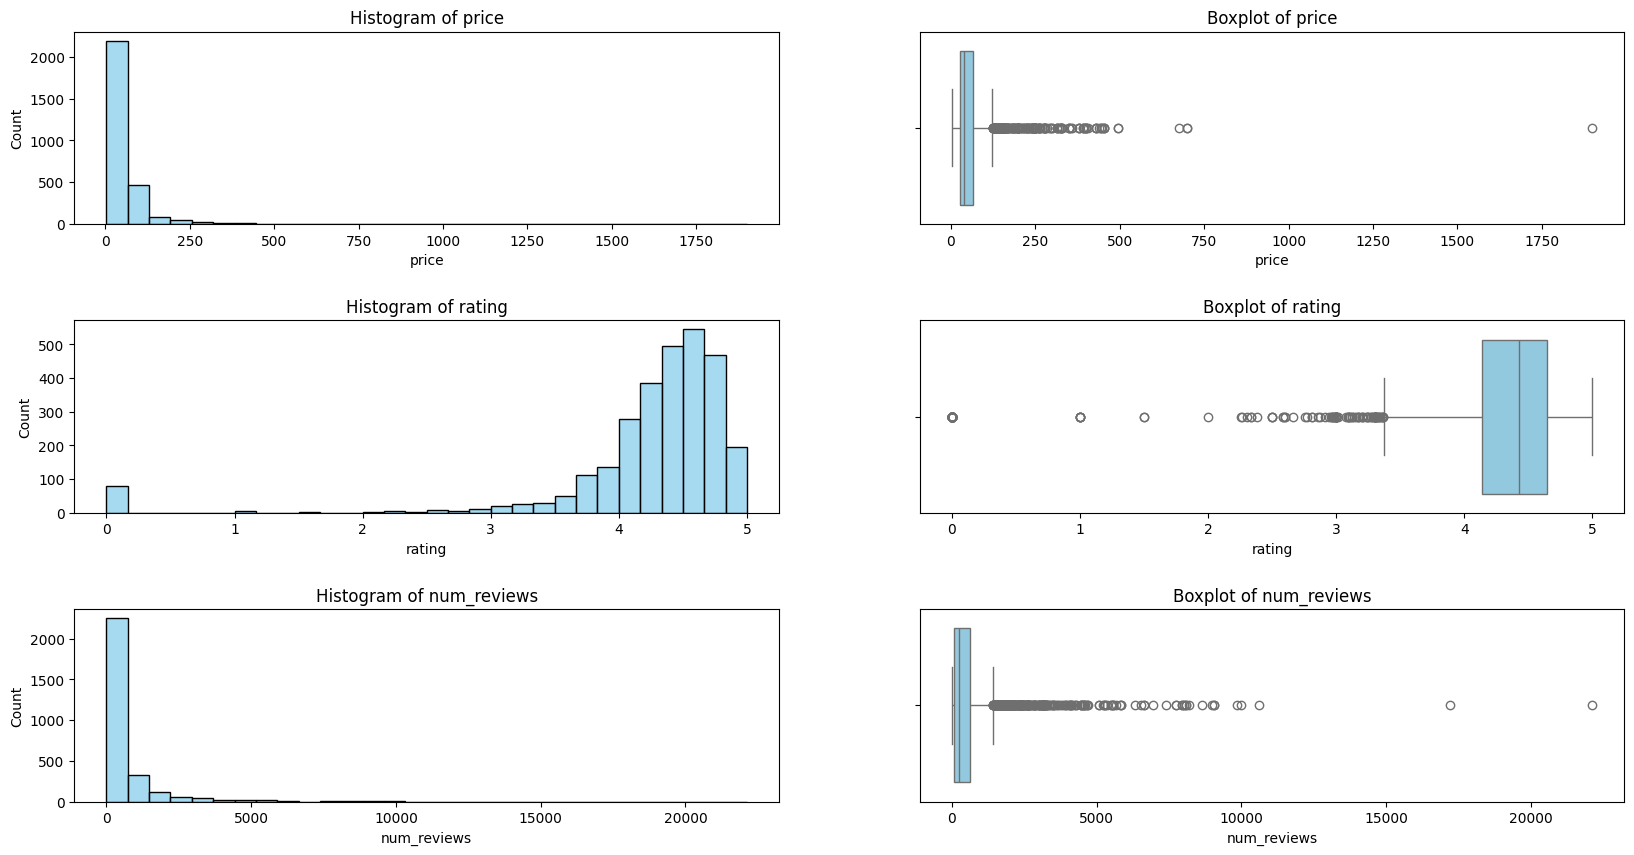

In [15]:
# 3. Distribution in numerical features

numeric_features = ['price', 'rating', 'num_reviews']

fig, axes = plt.subplots(len(numeric_features), 2, figsize=(20, 10))

for n, feat in enumerate(numeric_features):
    color = "skyblue"

    # Histogram
    sns.histplot(product_df[feat], bins=30, kde=False, color=color, ax=axes[n, 0])
    axes[n, 0].set_title(f'Histogram of {feat}')

    # Boxplot
    sns.boxplot(x=product_df[feat], color=color, ax=axes[n, 1])
    axes[n, 1].set_title(f'Boxplot of {feat}')
    
plt.subplots_adjust(hspace=0.5)
plt.show()

# 3. Data Preparation

In this section, we apply text preprocessing to gain a better understanding of the text data we have, and to bring it into a better state for extracting insights. We implement several steps based on our initial observations of the text characteristics. Here are the processes we performed:
1. Remove HTML entity decoding and tag removel
2. Remove URLs
3. Convert text to lowercase
4. Remove standalone number
4. Expand contractions
5. Convert emojis into interpretable text


Punctuation and stopwords will be excluded for visualisation only, as their removal can potentially cause the text to lose its genuine meaning that is important to retain for modeling. However, for exploratory visualisation, it is often beneficial to exclude common or unnecessary information in order to gain more meaningful insights.

In [ ]:
# Apply text preprocessing to the review_text column
from src.text_preprocessing import text_preprocessing_pipeline

pd.set_option('display.max_colwidth', None)

# Clean review titles
reviews_df['cleaned_review_title'] = reviews_df['review_title'].apply(lambda x: text_preprocessing_pipeline(x, emoji_mode="remove", remove_punctuation=False, remove_stopwords=False))

# Clean review texts, exploring both options for emoji handling
reviews_df['cleaned_review_text'] = reviews_df['review_text'].apply(lambda x: text_preprocessing_pipeline(x, emoji_mode="remove", remove_punctuation=False, remove_stopwords=False))
reviews_df['cleaned_demojize_review_text'] = reviews_df['review_text'].apply(lambda x: text_preprocessing_pipeline(x, emoji_mode="convert", remove_punctuation=False, remove_stopwords=False))

reviews_df[['review_text', 'cleaned_demojize_review_text']].head(3)

,review_text,cleaned_demojize_review_text
0,It’s so good and moisturizing that sometimes I use it as a moisturizer. I don’t need anything else. I’m on my 5th bottle and I love this so much. I even use it on my body.,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.
1,"I’m genuinely OBSESSED with this glazing milk 🤍 The texture is just everything—so lightweight, silky, and it melts into my skin instantly. It feels like a drink of water for my face every single time I use it.\n\nI keep it in my skincare fridge (yes, it’s that serious 😭) and using it cold makes the experience even better. It leaves my skin feeling SO smooth, like actual silk, and gives me that healthy, glowy finish without feeling heavy or greasy.\n\nI use it every single day and I’m not even kidding when I say I can’t go without it anymore. My skin just looks and feels so hydrated, calm, and fresh.\n\n10/10. I’m in love 💫","i am genuinely obsessed with this glazing milk white heart the texture is just everything—so lightweight, silky, and it melts into my skin instantly. it feels like a drink of water for my face every single time i use it. i keep it in my skincare fridge (yes, it is that serious loudly crying face ) and using it cold makes the experience even better. it leaves my skin feeling so smooth, like actual silk, and gives me that healthy, glowy finish without feeling heavy or greasy. i use it every single day and i am not even kidding when i say i cannot go without it anymore. my skin just looks and feels so hydrated, calm, and fresh. /. i am in love dizzy"
2,I had such high hopes for this product and was very disappointed in the outcome. I was looking for something I could use as a base before putting on makeup that would help with creating a glowy effect. My makeup would shift throughout the day and be patchy and honestly had never looked worse. I highly do not recommend using this product if you were planning on using it underneath makeup. Such a disappointment and waste of money!!,i had such high hopes for this product and was very disappointed in the outcome. i was looking for something i could use as a base before putting on makeup that would help with creating a glowy effect. my makeup would shift throughout the day and be patchy and honestly had never looked worse. i highly do not recommend using this product if you were planning on using it underneath makeup. such a disappointment and waste of money!!


In [16]:
# Ensure each column has the correct data type
reviews_df['review_id'] = reviews_df['review_id'].astype(str)

reviews_df['timestamp'] = pd.to_datetime(reviews_df['timestamp'], errors='coerce')
reviews_df['year'] = reviews_df['timestamp'].dt.year

reviews_df.head(1)

,product_id,review_id,rating,review_title,review_text,timestamp,reviewer_nickname,cleaned_review_title,cleaned_review_text,cleaned_demojize_review_title,cleaned_demojize_review_text,year
0,P519160,382076916,5,A must have for me,It’s so good and moisturizing that sometimes I use it as a moisturizer. I don’t need anything else. I’m on my 5th bottle and I love this so much. I even use it on my body.,2026-03-19 19:12:57+00:00,Melanie803,a must have for me,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.,a must have for me,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.,2026


In [ ]:
# Remove rows with missing or empty cleaned review text
mask = (reviews_df['cleaned_review_text']
        .notna() &
        (reviews_df['cleaned_review_text'].str.strip() != ''))

reviews_df_notna = reviews_df[mask].copy()

In [ ]:
# Semantic chunking of reviews
from src.semantic_chunking import chunk_reviews
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

chunks_df = chunk_reviews(reviews_df, model, percentile=25, min_sentences=3)

print(f"Original reviews : {len(reviews_df)}")
print(f"Total chunks     : {len(chunks_df)}")
# print(f"Avg chunks/review: {chunks_df.groupby('review_id')['n_chunks'].max().mean():.2f}")

print(f"Original reviews : 1710285")
print(f"Total chunks     : 2214276")

Original reviews : 1710285
Total chunks     : 2214276


# 4. Exploratory Visualisation

In this section, we use visualisation to understand the distribution and frequency of the words in the review text, that way we can identify the common themes or patterns in how consumers write their reviews.

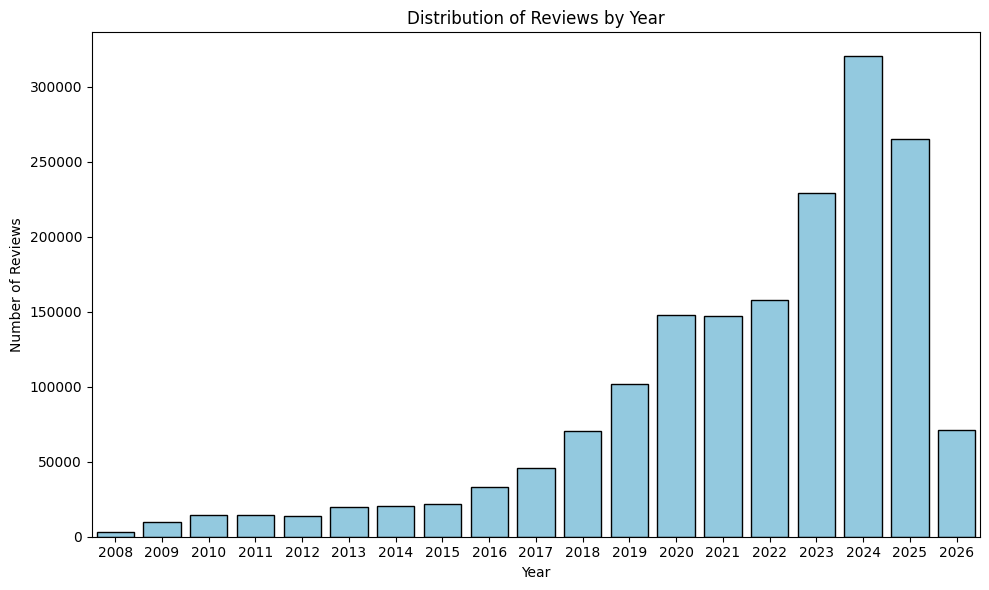

In [22]:
# Calculate the count of reviews by year
count_by_year = reviews_df['year'].value_counts().sort_index()
years = sorted(reviews_df['year'].unique())

# Plot the distribution of reviews by year
plt.figure(figsize=(10, 6))
sns.barplot(x=years, y=count_by_year[years], color='skyblue', edgecolor='black')
plt.title('Distribution of Reviews by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

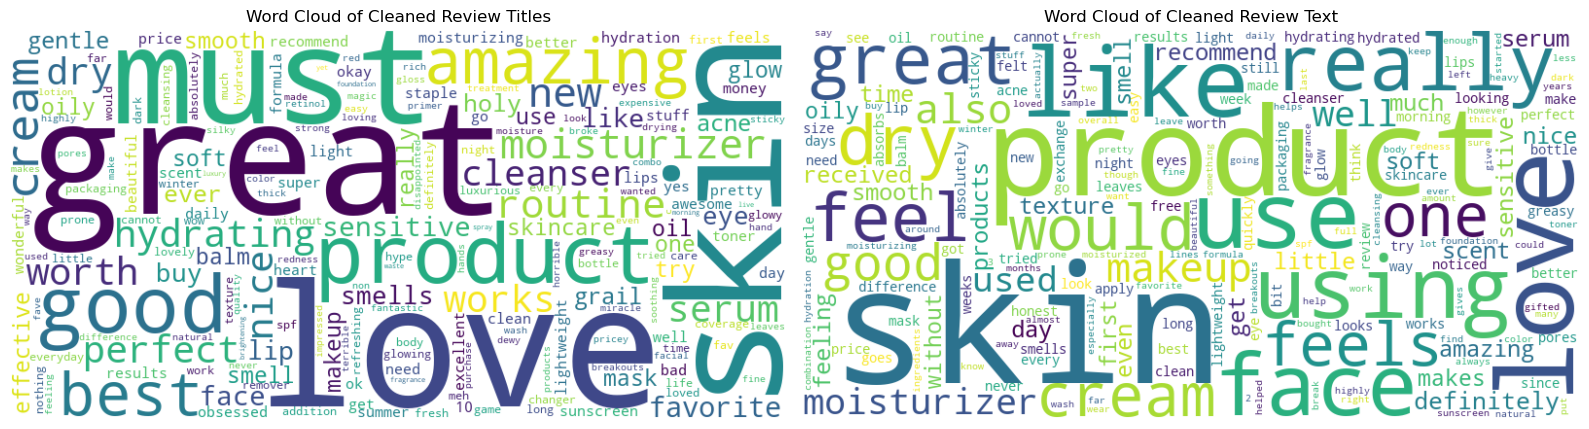

In [11]:
from wordcloud import WordCloud
from collections import Counter

# Combine text
all_title_text   = ' '.join(reviews_df['cleaned_review_title'].dropna())
all_reviews_text = ' '.join(reviews_df['cleaned_review_text'].dropna())

# Word frequencies
title_freq   = Counter(all_title_text.split())
reviews_freq = Counter(all_reviews_text.split())

del title_freq['nan'] 

# Plot for word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, freq, title in zip(
    axes,
    [title_freq, reviews_freq],
    ['Word Cloud of Cleaned Review Titles', 'Word Cloud of Cleaned Review Text']):
    
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

plt.tight_layout()
plt.show()

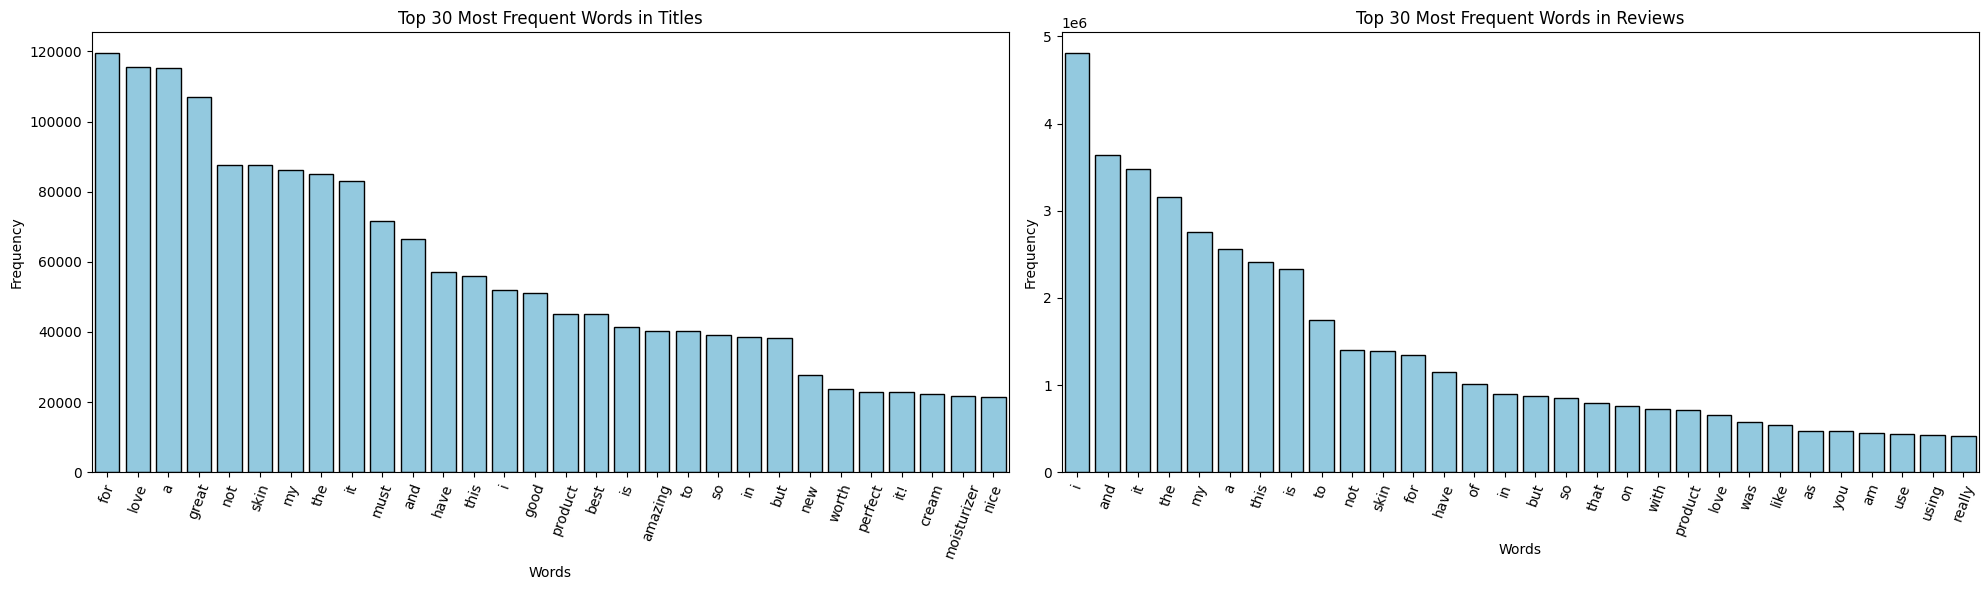

In [21]:
# Plot for bar charts of most common words
most_com = 30
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, freq, title in zip(
    axes,
    [title_freq, reviews_freq],
    [f'Top {most_com} Most Frequent Words in Titles',
     f'Top {most_com} Most Frequent Words in Reviews']):
    
    words, counts = zip(*freq.most_common(most_com))
    sns.barplot(x=list(words), y=list(counts), ax=ax, color='skyblue', edgecolor='black')
    ax.set_xlabel('Words')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

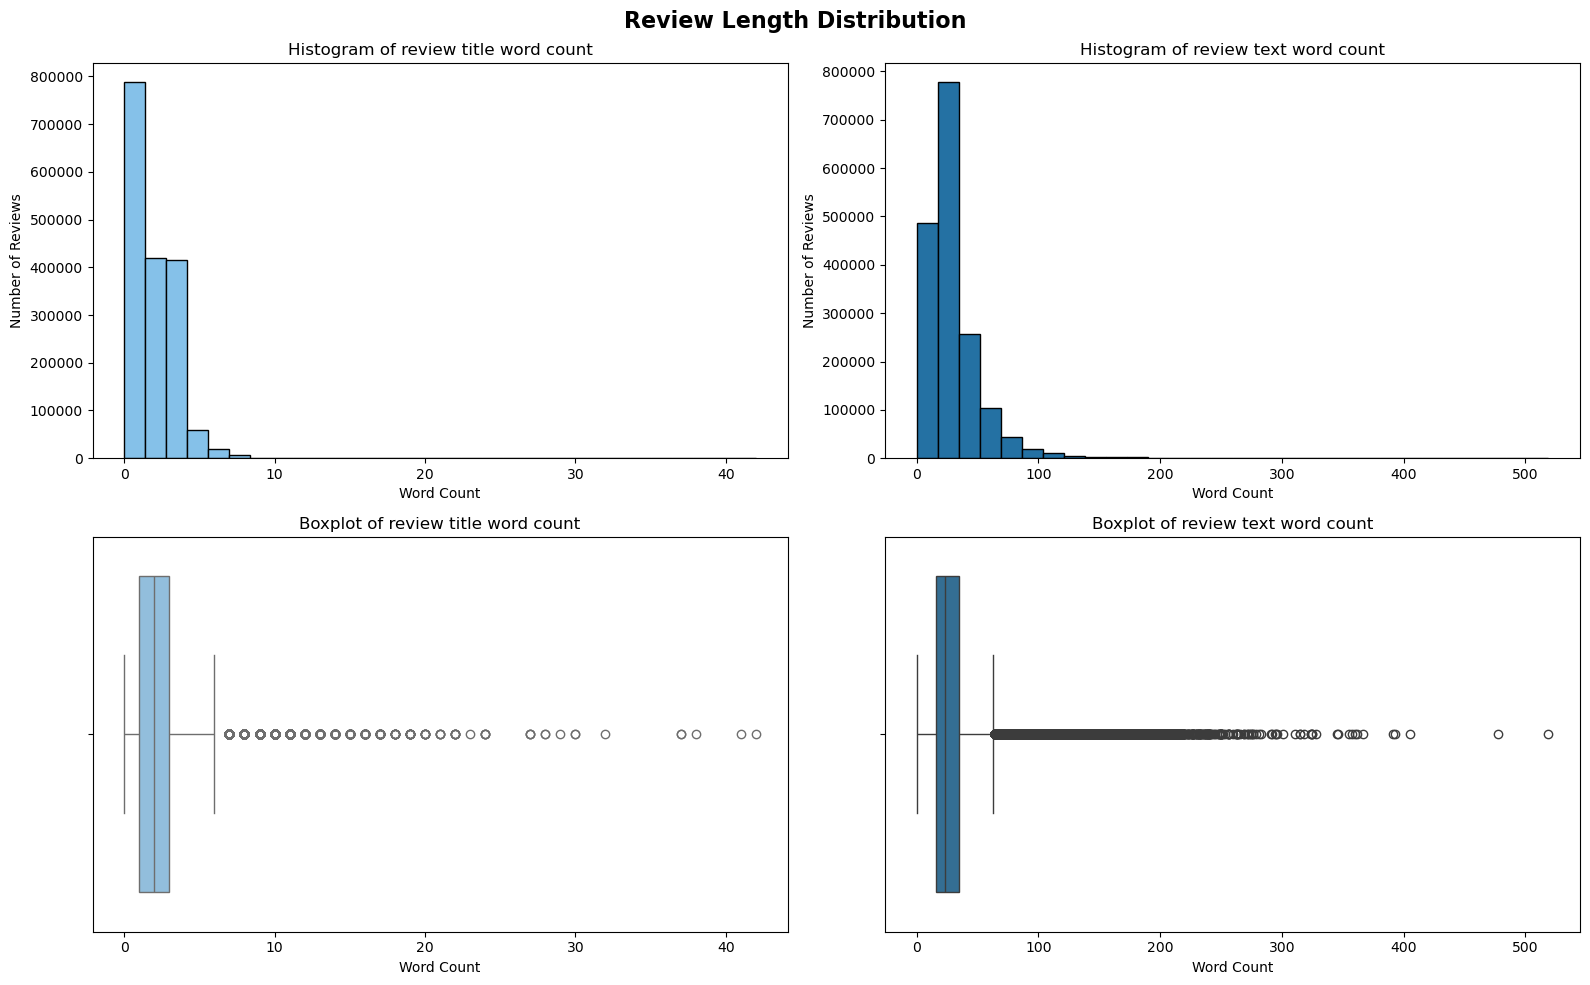

,Title Word Count,Review Word Count
count,1710285.0,1710285.0
mean,2.0,29.1
std,1.3,21.2
min,0.0,0.0
25%,1.0,16.0
50%,2.0,23.0
75%,3.0,35.0
max,42.0,519.0


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate word counts per review
reviews_df['title_word_count']  = reviews_df['cleaned_review_title'].dropna().apply(lambda x: len(str(x).split()))
reviews_df['review_word_count'] = reviews_df['cleaned_review_text'].dropna().apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Review Length Distribution', fontsize=16, fontweight='bold')

# Histogram: Title Word Count
axes[0, 0].hist(reviews_df['title_word_count'].dropna(), bins=30, color='#85C1E9', edgecolor='black')
axes[0, 0].set_title('Histogram of review title word count')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Reviews')

# Histogram: Review Text Word Count
axes[0, 1].hist(reviews_df['review_word_count'].dropna(), bins=30, color='#2471A3', edgecolor='black')
axes[0, 1].set_title('Histogram of review text word count')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Reviews')

# Boxplot: Title Word Count
sns.boxplot(x=reviews_df['title_word_count'].dropna(), ax=axes[1, 0], color='#85C1E9')
axes[1, 0].set_title('Boxplot of review title word count')
axes[1, 0].set_xlabel('Word Count')

# Boxplot: Review Text Word Count
sns.boxplot(x=reviews_df['review_word_count'].dropna(), ax=axes[1, 1], color='#2471A3')
axes[1, 1].set_title('Boxplot of review text word count')
axes[1, 1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# Summary statistics for title and review word counts
summary_df = pd.DataFrame({
    'Title Word Count'  : reviews_df['title_word_count'].describe(),
    'Review Word Count' : reviews_df['review_word_count'].describe()
}).round(1)

summary_df

# 5. Topic modeling

We load the chunks and apply BERTopic to them. The process involves `UMAP` for dimensionality reduction, `HDBSCAN` for clustering, and `CountVectorizer` for unigram and bigram topic representation. The topic modeling results in 100 topics, with each review assigned to a topic, along with a dendrogram.

In [4]:
# Import cleaned reviews to skip re-running the text preprocessing
import pandas as pd

clean_reviews_df = pd.read_csv("./data/sephora_review_chunks.csv")
cleaned_texts = clean_reviews_df['review_chunk'].tolist()

print(clean_reviews_df.shape)
pd.set_option('display.max_colwidth', None)
clean_reviews_df[clean_reviews_df['n_chunks']>1].iloc[:, :4].tail(6)

(2214276, 10)


,review_id,chunk_pos,n_chunks,review_chunk
2214248,381229512,0,2,"this is so powerful. i love how it just goes right on. and you can layer it, it smells. so good. and it also has the perfect blending experience. i cannot even explain how easily it blends into either light or dark skin. really? it gives you that perfect glow."
2214249,381229512,1,2,"it is not transferable, it is got a little bit of shine to it but it is definitely not glitter. it just gives you that summer glow and it looks so natural. does not look fake at all. it is so beautiful. it is easy to travel with easy to apply.it is the perfect on the go, everyday solution ."
2214250,381169861,0,2,"i am loving this product; it gives me the perfect contoured look. i sculpted my face with this product, and it gives the most natural look. i love waking up looking freshly tanned and warm."
2214251,381169861,1,2,"the application is super simple, and it lasts for up to days. there is also no need to wash off it will fade on its own, which i really like. i will definitely be repurchasing this item and recommending it to my friends. as someone who is light-skinned and losing color in the winter, this gives me a summer glowy tan all year round!"
2214252,380571286,0,2,"after using this product over the past few weeks, i am loving the results! it has made my makeup routine in the morning easier. application is easy, and the formula is smooth and smells nice."
2214253,380571286,1,2,i highly recommend it.


In [ ]:
### Generate sentence embeddings for topic modeling
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

# Define embeddings model
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')

embeddings_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Generate embeddings and save to file to avoid re-computation
embeddings = embeddings_model.encode(cleaned_texts,
                                     show_progress_bar=True,
                                     batch_size=64)

np.save('embeddings.npy', embeddings)

Device: mps
Total clean texts without NaN: 1708523


Batches:   0%|          | 0/26696 [00:00<?, ?it/s]

In [ ]:
### Topic Modeling with BERTopic

import numpy as np
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Define UMAP model for dimensionality reduction
umap_model = UMAP(n_neighbors=100,            # tune to control the topic granularity (lower = more topics - local structure, higher = fewer topics - global structure)
                  n_components=5,             # dimensionality reduction for HDBSCAN clustering
                  min_dist=0.0,
                  metric='cosine',
                  random_state=42)

# Define HDBSCAN model for clustering
hdbscan_model = HDBSCAN(min_cluster_size=1000, # tune to control the minimum size of clusters (topics)
                        min_samples=50,        # tune to control the sensitivity to noise (lower = more clusters, higher = fewer clusters)
                        metric='euclidean', 
                        cluster_selection_method='eom', 
                        prediction_data=True)

# Define CountVectorizer for topic representation
vectorizer_model = CountVectorizer(ngram_range=(1, 2),    # to capture unigrams and bigrams topics
                                   stop_words='english',
                                   min_df=0.01)            # ignore words that appear in less than 20 documents

# Create BERTopic model
embeddings = np.load('newEra/desy/embeddings.npy')
topic_model = BERTopic(umap_model=umap_model,
                       hdbscan_model=hdbscan_model,
                       vectorizer_model=vectorizer_model,
                       top_n_words=10,                    # number of words to represent each topic
                       nr_topics=None,
                       calculate_probabilities=True,
                       verbose=True)

topics, probabilities = topic_model.fit_transform(cleaned_texts, embeddings)
topic_model.save("bertopic_model")

# Reduce topics after fitting
topic_model.reduce_topics(cleaned_texts, nr_topics=100)

# Recompute probabilities after reduction
topics = topic_model.topics_
probabilities = topic_model.probabilities_

# Save the BERTopic model
topic_model.save("bertopic_model_reduced")

# Save the topic summary
topic_info = topic_model.get_topic_info()
topic_info.to_csv("topic_summary.csv", index=False)

# Save the document-topic assignments with all probabilities
docs_data = []

for i, doc in enumerate(cleaned_texts):
    prob_row = probabilities[i]
    main_topic = topics[i]
    main_prob = prob_row[main_topic] if main_topic != -1 else 0.0
    
    row = {
        "review_text": doc,
        "main_topic": main_topic,
        "main_prob": main_prob
    }
    
    docs_data.append(row)

docs_df = pd.DataFrame(docs_data)
prob_df = pd.DataFrame(probabilities, columns=[f"topic_{i}" for i in range(probabilities.shape[1])])
docs_df = pd.concat([docs_df, prob_df], axis=1)
docs_df.to_csv("reviews_with_probs.csv", index=False)

/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-05 10:23:29,326 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 12:32:25,714 - BERTopic - Dimensionality - Completed ✓
2026-04-05 12:32:25,746 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 13:33:34,052 - BERTopic - Cluster - Completed ✓
2026-04-05 13:33:34,295 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 13:34:53,471 - BERTopic - Representation - Completed ✓
2026-04-05 13:35:05,445 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 13:35:06,247 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 13:36:32,588 - BERTopic - Representation - Completed ✓
2

In [13]:
from IPython.display import HTML

# Display the dendrogram (hierarchical clustering of topics)
topic_model.reduce_topics(cleaned_texts, nr_topics=100)
hierarchical_topics = topic_model.hierarchical_topics(cleaned_texts)
fig = topic_model.visualize_hierarchy(hierarchical_topics = hierarchical_topics)
fig.write_html("topic_dendrogram.html")

fig_html = fig.to_html(full_html=False)
display(HTML(fig_html))

100%|██████████| 98/98 [00:11<00:00,  8.67it/s]


In [4]:
topic_model.reduce_topics(cleaned_texts, nr_topics=100)
hierarchical_topics = topic_model.hierarchical_topics(cleaned_texts)
fig = topic_model.visualize_hierarchy(hierarchical_topics = hierarchical_topics)
fig.write_image("topic_dendrogram.png", width=1600, height=900, scale=2)

100%|██████████| 48/48 [00:07<00:00,  6.45it/s]


# 6. Labeled Dataset Construction

The process of constructing the labeled dataset begins with assigning each review to the corresponding aspects based on the topic-to-aspect mapping. 

**The first iteration of sampling** is conducted using stratified sampling by year and aspect, targeting 400 samples for each aspect.

In [ ]:
### Define topic to aspect mapping from BERTopic results

topic_to_aspect = {
    # Acne & Blemish Control
    9: "Acne & Blemish Control", 
    78: "Acne & Blemish Control", 92: "Acne & Blemish Control",
    98: "Acne & Blemish Control",
    # Anti-Aging & Skin Renewal
    6: "Anti-Aging & Skin Renewal", 25: "Anti-Aging & Skin Renewal",
    26: "Anti-Aging & Skin Renewal", 77: "Anti-Aging & Skin Renewal",
    95: "Anti-Aging & Skin Renewal",
    # Cleansing & Exfoliation
    3: "Cleansing & Exfoliation", 10: "Cleansing & Exfoliation",
    24: "Cleansing & Exfoliation", 61: "Cleansing & Exfoliation",
    66: "Cleansing & Exfoliation",
    # Consistency & Texture
    62: "Consistency & Texture", 49: "Consistency & Texture",
    2: "Consistency & Texture",  35: "Consistency & Texture",
    57: "Consistency & Texture", 79: "Consistency & Texture",
    80: "Consistency & Texture", 63: "Consistency & Texture",
    34: "Consistency & Texture", 76: "Consistency & Texture",
    # Hydration & Moisturization
    4: "Hydration & Moisturization", 11: "Hydration & Moisturization",
    0: "Hydration & Moisturization", 12: "Hydration & Moisturization",
    16: "Hydration & Moisturization", 42: "Hydration & Moisturization",
    82: "Hydration & Moisturization", 94: "Hydration & Moisturization",
    1: "Hydration & Moisturization",
    # Packaging & Size
    22: "Packaging & Size", 27: "Packaging & Size", 40: "Packaging & Size",
    41: "Packaging & Size", 51: "Packaging & Size", 74: "Packaging & Size",
    81: "Packaging & Size", 70: "Packaging & Size", 50: "Packaging & Size",
    53: "Packaging & Size",
    # Skin Sensitivity
    7: "Skin Sensitivity", 
    # Skin Tone & Pigmentation
    5: "Skin Tone & Pigmentation", 29: "Skin Tone & Pigmentation",
    54: "Skin Tone & Pigmentation",
    # Sun Protection
    8: "Sun Protection", 52: "Sun Protection",
    # Wear & Longevity
    97: "Wear & Longevity", 55: "Wear & Longevity",
    65: "Wear & Longevity", 84: "Wear & Longevity",
}

topics_df = pd.read_csv("reviews_with_probs.csv")
aspect_df = topics_df[['review_id', 'year', 'main_topic', 'rating', 'cleaned_review_text', 'cleaned_demojize_review_text', 'cleaned_review_title']].copy()
aspect_df["aspect"] = aspect_df["main_topic"].map(topic_to_aspect)
aspect_df = aspect_df[aspect_df["aspect"].notna()].copy()

cols = list(aspect_df.columns)
cols.insert(1, cols.pop(cols.index('aspect')))
aspect_df = aspect_df[cols]

# Save aspect_df for further analysis
aspect_df.to_csv("reviews_aspect_df.csv", index=False)

In [15]:
### Import the reviews with assigned topics and aspects mapping

topics_df = pd.read_csv("data/reviews_aspect_df.csv")
topics_df.head(3)

,review_id,aspect,year,main_topic,rating,cleaned_review_text,cleaned_demojize_review_text,cleaned_review_title
0,381986542,Packaging & Size,2026,41,5,"i had the mini one, and i had to get the big o...","i had the mini one, and i had to get the big o...",absolutely will be repurchasing
1,381957906,Hydration & Moisturization,2026,0,5,i am loving this product. using from last 2mon...,i am loving this product. using from last 2mon...,NaN
2,381808454,Hydration & Moisturization,2026,11,2,it is literally ok i have tried better milky t...,it is literally ok i have tried better milky t...,do not


In [ ]:
### First iteration: Stratified sampling for ABSA labelling
from src.data_sampling import sample_for_manually_labelled_set

sample_df = sample_for_manually_labelled_set(aspect_df, text_col="cleaned_review_text", n_per_aspect=410, seed=42)

Total samples : 4070

Samples per aspect per year:
year                        2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
aspect                                                                                      
Acne & Blemish Control        37    37    37    37    37    37    37    37    37    37    37
Anti-Aging & Skin Renewal     37    37    37    37    37    37    37    37    37    37    37
Cleansing & Exfoliation       37    37    37    37    37    37    37    37    37    37    37
Consistency & Texture         37    37    37    37    37    37    37    37    37    37    37
Hydration & Moisturization    37    37    37    37    37    37    37    37    37    37    37
Packaging & Size              37    37    37    37    37    37    37    37    37    37    37
Skin Sensitivity              37    37    37    37    37    37    37    37    37    37    37
Skin Tone & Pigmentation      37    37    37    37    37    37    37    37    37    37    37
Sun Protection     

**The second iteration of sampling** is conducted using targeted keyword sampling for negative and neutral samples. It is also combined with augmentation to achieve the target numbers of 280 positives, 100 negatives, 80 neutrals, and 100 not_mentioned.

In [23]:
# Load first iteration of manually labelled data
import pandas as pd

aspect_df = pd.read_excel("data/initial_samples_with_labels.xlsx")
display(aspect_df.head(3))

aspect_df.groupby(['aspect','label']).size().unstack(fill_value=0)

,review_id,aspect,year,main_topic,rating,cleaned_review_text,cleaned_demojize_review_text,cleaned_review_title,label
0,58645662,Acne & Blemish Control,2016,9,4,what is interesting is i bought this product t...,what is interesting is i bought this product t...,pores no more,positive
1,77914685,Acne & Blemish Control,2016,9,5,this literally just came in the mail hours ago...,this literally just came in the mail hours ago...,amazingggggg,positive
2,61158497,Acne & Blemish Control,2016,9,5,no more breakouts! give it time and you will s...,no more breakouts! give it time and you will s...,love it,positive


label,negative,neutral,not_mentioned,positive
aspect,,,,
Acne & Blemish Control,62,23,9,312
Anti-Aging & Skin Renewal,32,9,133,232
Cleansing & Exfoliation,33,9,30,335
Consistency & Texture,88,15,32,269
Hydration & Moisturization,15,9,71,304
Packaging & Size,80,17,40,261
Skin Sensitivity,82,16,18,289
Skin Tone & Pigmentation,32,5,160,209
Sun Protection,37,21,8,339


In [ ]:
### Second iteration: Targeted resampling to achieve 280 positives, 100 negatives, 80 neutrals, and 100 not_mentioned per aspect
from src.data_sampling import _remaining_targets, run_targeted_resampling

targets_per_label = {
    "positive"     : 280,
    "negative"     : 100,
    "neutral"      : 80,
    "not_mentioned": 100,
}

remaining_targets = _remaining_targets(aspect_df, targets_per_label)

updated_labelled_df, resample_df, augment_df = run_targeted_resampling(aspect_df, combined_df, targets=remaining_targets, label_col='label', seed=42)

Lastly, we **combine the samples** from the first and second iterations, including targeted and augmented samples. The combined dataset achieves the target sample size to proceed to ABSA

In [18]:
import pandas as pd
import numpy as np

sampling_df = pd.read_excel("data/initial_samples_with_labels.xlsx")
resampling_df = pd.read_excel("data/resample_with_labels.xlsx")
augment_df = pd.read_excel("data/augmented_samples.xlsx")

print("Sampling dataframe:", sampling_df.shape[0])
sampling_df['note'] = 'initial_sample'
display(sampling_df.head(3))

print("Resampling dataframe:", resampling_df.shape[0])
display(resampling_df.head(3))

print("Augment dataframe:", augment_df.shape[0])
augment_df['note'] = np.where(augment_df['note'].str.contains('augmented', na=False),
                              'back_translation',
                              'llm_paraphrased')
display(augment_df.head(3))

Sampling dataframe: 4043


,review_id,aspect,year,main_topic,rating,cleaned_review_text,cleaned_demojize_review_text,cleaned_review_title,label,note
0,58645662,Acne & Blemish Control,2016,9,4,what is interesting is i bought this product t...,what is interesting is i bought this product t...,pores no more,positive,initial_sample
1,77914685,Acne & Blemish Control,2016,9,5,this literally just came in the mail hours ago...,this literally just came in the mail hours ago...,amazingggggg,positive,initial_sample
2,61158497,Acne & Blemish Control,2016,9,5,no more breakouts! give it time and you will s...,no more breakouts! give it time and you will s...,love it,positive,initial_sample


Resampling dataframe: 1509


,review_id,aspect,year,main_topic,rating,cleaned_review_text,cleaned_demojize_review_text,cleaned_review_title,label,note
0,379583992,Acne & Blemish Control,2026,6,5,i am only using it at night for only four days...,i am only using it at night for only four days...,buy it. you will not regret it,not_mentioned,resample_not_mentioned
1,212736533,Acne & Blemish Control,2022,16,5,this smells amazing. i repurchased twice alrea...,this smells amazing. i repurchased twice alrea...,NaN,not_mentioned,resample_not_mentioned
2,188785105,Acne & Blemish Control,2021,2,4,i enjoyed this body wash. it has a more earthy...,i enjoyed this body wash. it has a more earthy...,eucalyptus scent is nice,not_mentioned,resample_not_mentioned


Augment dataframe: 679


,review_id,aspect,year,main_topic,rating,cleaned_review_text,cleaned_review_title,label,note
0,63752950,Acne & Blemish Control,2016,9,4,I bought this product a week ago and applied i...,it's better than okay,neutral,back_translation
1,74607299,Acne & Blemish Control,2016,9,5,I'm in my early years and have combination ski...,holy grail!!,neutral,back_translation
2,74853266,Acne & Blemish Control,2016,98,3,Every time I get new pimples and want to get r...,Short-term results will not help in the long t...,neutral,back_translation


In [ ]:
# Combine the two dataframes
combined_df = pd.concat([sampling_df, resampling_df, augment_df], ignore_index=True)

print("Combined dataframe", combined_df.shape[0])
combined_df.head(3)

Combined dataframe 6231


,review_id,aspect,year,main_topic,rating,cleaned_review_text,cleaned_demojize_review_text,cleaned_review_title,label,note
0,58645662,Acne & Blemish Control,2016,9,4,what is interesting is i bought this product t...,what is interesting is i bought this product t...,pores no more,positive,initial_sample
1,77914685,Acne & Blemish Control,2016,9,5,this literally just came in the mail hours ago...,this literally just came in the mail hours ago...,amazingggggg,positive,initial_sample
2,61158497,Acne & Blemish Control,2016,9,5,no more breakouts! give it time and you will s...,no more breakouts! give it time and you will s...,love it,positive,initial_sample


In [3]:
# Downsampling for not_mentioned and positive classes to balance the dataset for model training
from src.data_sampling import trim_labelled_set

targets = {"positive"      : 280,
           "negative"      : 100,
           "neutral"       : 80,
           "not_mentioned" : 100}

labelled_df = trim_labelled_set(combined_df, targets, seed=42)

In [4]:
# Show the labels distribution in the combined dataframe
labelled_df.groupby(['aspect', 'label']).size().unstack(fill_value=0)

label,negative,neutral,not_mentioned,positive
aspect,,,,
Acne & Blemish Control,100,80,100,280
Anti-Aging & Skin Renewal,100,80,100,280
Cleansing & Exfoliation,100,80,100,280
Consistency & Texture,100,80,100,280
Hydration & Moisturization,100,80,100,280
Packaging & Size,100,80,100,280
Skin Sensitivity,100,80,100,280
Skin Tone & Pigmentation,100,80,100,280
Sun Protection,100,80,100,280


/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9783.80it/s]
/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


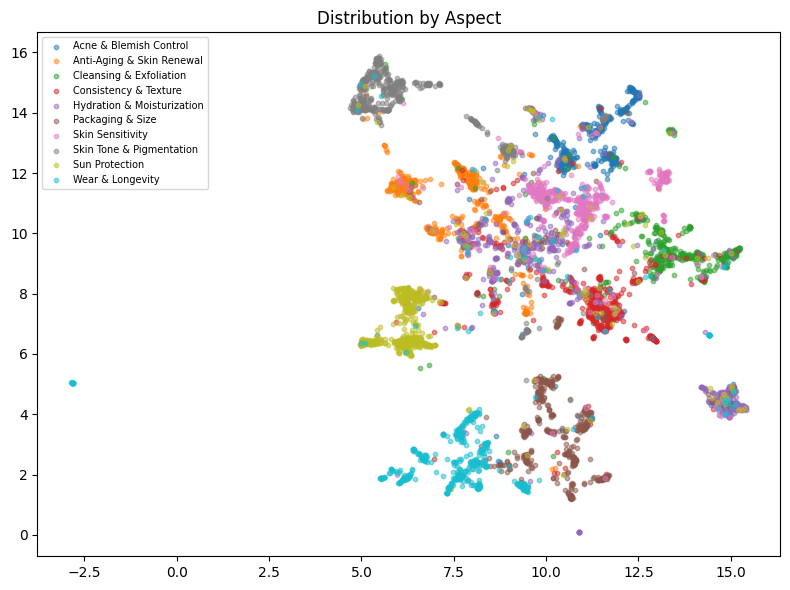

In [5]:
### UMAP Visualizationt for quality checking the manual labels

from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt

model     = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(labelled_df["cleaned_review_text"].tolist())

reducer   = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(8, 6))

# Plot by aspect
for aspect in labelled_df["aspect"].unique():
    mask = labelled_df["aspect"] == aspect
    plt.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], label=aspect, alpha=0.5, s=10)

plt.legend(fontsize=7)
plt.title("Distribution by Aspect")
plt.tight_layout()
plt.show()

We also performed a final check using UMAP to examine the separation between aspect labels. The result shows clear separation between aspect labels and supported our decision to proceed with modeling.

# 7. Aspect-based Sentiment Analysis

In this section, we perform an ablation study on ABSA using baseline and fine-tuned models with progressively unfrozen layers. We begin by splitting the labeled dataset into training, validation, and test sets. The performance results for each configuration are shown below.

In [ ]:
### Split the labeled dataset into train, validation, and test sets with stratification by aspect and label
from src.data_sampling import split_labelled_set

train_df, val_df, test_df = split_labelled_set(labelled_df, label_col="label")

Train set: 3920 samples
Validation set: 840 samples
Test set: 840 samples


/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4588.18it/s]


Best threshold: 0.4  (F1 macro=0.4886)
  positive             Precision = 0.660  Recall = 0.960  F1 = 0.782  N = 420
  negative             Precision = 0.692  Recall = 0.793  F1 = 0.739  N = 150
  neutral              Precision = 0.661  Recall = 0.308  F1 = 0.420  N = 120
  not_mentioned        Precision = 1.000  Recall = 0.007  F1 = 0.013  N = 150

  Macro F1  : 0.4886
  Accuracy  : 0.6667


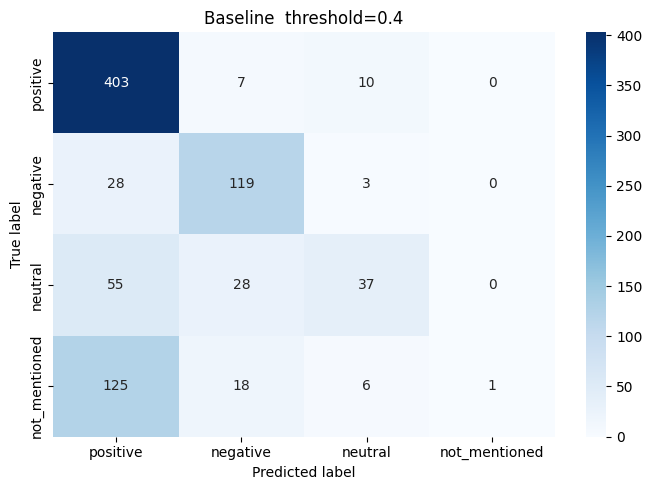

In [ ]:
### Baseline
from src.absa_model import run_baseline

pred_df, sweep_df = run_baseline(val_df)


 FINE TUNING: n_unfreeze=0 | device=cuda


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 3704.03it/s]


Trainable params: (0.3%)
Epoch 1/15  train_loss=1.0657  val_loss=0.8610  macro_F1=0.5452
  Saved best checkpoint to outputs/best_model_unfreeze0
Epoch 2/15  train_loss=0.8654  val_loss=0.8126  macro_F1=0.5652
  Saved best checkpoint to outputs/best_model_unfreeze0
Epoch 3/15  train_loss=0.8337  val_loss=0.8061  macro_F1=0.5686
  Saved best checkpoint to outputs/best_model_unfreeze0
Epoch 4/15  train_loss=0.8125  val_loss=0.7607  macro_F1=0.5813
  Saved best checkpoint to outputs/best_model_unfreeze0
Epoch 5/15  train_loss=0.7871  val_loss=0.7632  macro_F1=0.5976
  No improvement (1/5)
Epoch 6/15  train_loss=0.7805  val_loss=0.7222  macro_F1=0.5984
  Saved best checkpoint to outputs/best_model_unfreeze0
Epoch 7/15  train_loss=0.7738  val_loss=0.7572  macro_F1=0.6380
  No improvement (1/5)
Epoch 8/15  train_loss=0.7703  val_loss=0.7012  macro_F1=0.6028
  Saved best checkpoint to outputs/best_model_unfreeze0
Epoch 9/15  train_loss=0.7560  val_loss=0.7183  macro_F1=0.5985
  No improvement 

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4535.62it/s]


  positive             Precision = 0.765  Recall = 0.914  F1 = 0.833  N = 420
  negative             Precision = 0.772  Recall = 0.813  F1 = 0.792  N = 150
  neutral              Precision = 0.697  Recall = 0.883  F1 = 0.779  N = 120
  not_mentioned        Precision = 0.393  Recall = 0.073  F1 = 0.124  N = 150

  Macro F1  : 0.6320
  Accuracy  : 0.7417


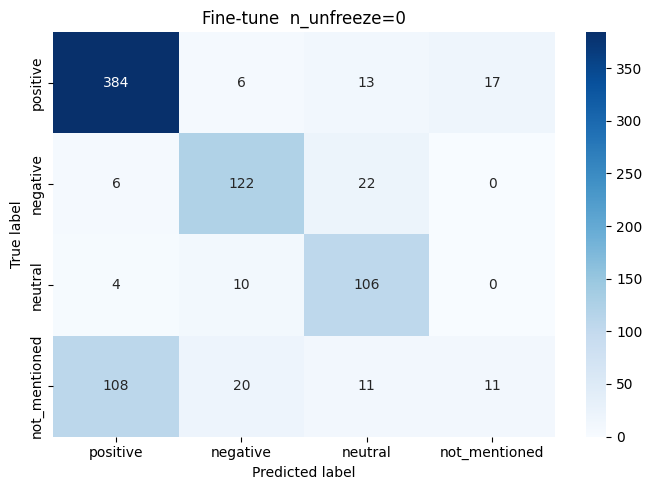

In [ ]:
### Fine-tune 1: classifier head with no unfreezing layers
from src.absa_model import run_finetune

model_head, history_head = run_finetune(train_df, val_df,
                                        output_dir   = "outputs",
                                        n_unfreeze   = 0,
                                        epochs       = 15,
                                        batch_size   = 16,
                                        lr           = 2e-5,
                                        head_lr_mult = 10.0,
                                        patience     = 5)

/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



 FINE TUNING: n_unfreeze=1 | device=cuda


Trainable params: (4.2%)
Epoch 1/15  train_loss=1.0796  val_loss=0.8449  macro_F1=0.5508
  Saved best checkpoint to outputs/best_model_unfreeze1
Epoch 2/15  train_loss=0.8347  val_loss=0.7571  macro_F1=0.6247
  Saved best checkpoint to outputs/best_model_unfreeze1
Epoch 3/15  train_loss=0.7745  val_loss=0.6998  macro_F1=0.6443
  Saved best checkpoint to outputs/best_model_unfreeze1
Epoch 4/15  train_loss=0.7410  val_loss=0.6978  macro_F1=0.6182
  Saved best checkpoint to outputs/best_model_unfreeze1
Epoch 5/15  train_loss=0.7101  val_loss=0.6868  macro_F1=0.6321
  Saved best checkpoint to outputs/best_model_unfreeze1
Epoch 6/15  train_loss=0.6990  val_loss=0.6515  macro_F1=0.6356
  Saved best checkpoint to outputs/best_model_unfreeze1
Epoch 7/15  train_loss=0.6737  val_loss=0.6262  macro_F1=0.6785
  Saved best checkpoint to outputs/best_model_unfreeze1
Epoch 8/15  train_loss=0.6555  val_loss=0.6460  macro_F1=0.6924
  No improvement (1/5)
Epoch 9/15  train_loss=0.6338  val_loss=0.6284  

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4934.50it/s]


  positive             Precision = 0.821  Recall = 0.831  F1 = 0.826  N = 420
  negative             Precision = 0.821  Recall = 0.827  F1 = 0.824  N = 150
  neutral              Precision = 0.776  Recall = 0.925  F1 = 0.844  N = 120
  not_mentioned        Precision = 0.438  Recall = 0.353  F1 = 0.391  N = 150

  Macro F1  : 0.7213
  Accuracy  : 0.7583


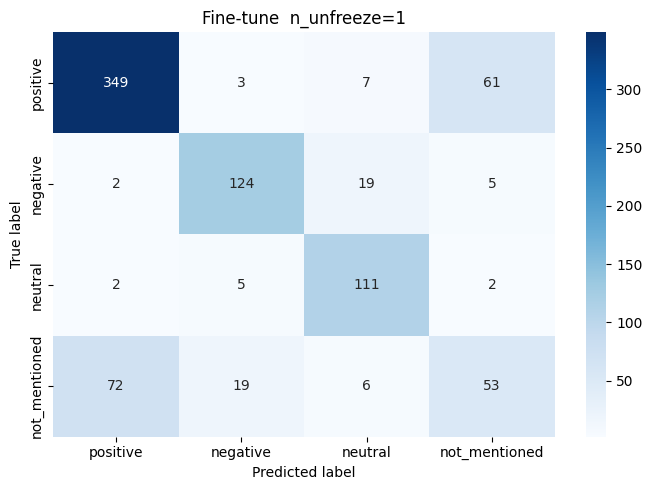

In [ ]:
### Fine-tune 2: classifier head with 1 unfreezing layer
from src.absa_model import run_finetune

model2_head, history2_head = run_finetune(train_df, val_df,
                                        output_dir   = "outputs",
                                        n_unfreeze   = 1,
                                        epochs       = 15,
                                        batch_size   = 16,
                                        lr           = 2e-5,
                                        head_lr_mult = 10.0,
                                        patience     = 5)

/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



 FINE TUNING: n_unfreeze=2 | device=cuda


Trainable params: (8.0%)
Epoch 1/15  train_loss=1.0852  val_loss=0.8028  macro_F1=0.5800
  Saved best checkpoint to outputs/best_model_unfreeze2
Epoch 2/15  train_loss=0.7839  val_loss=0.6920  macro_F1=0.6113
  Saved best checkpoint to outputs/best_model_unfreeze2
Epoch 3/15  train_loss=0.7127  val_loss=0.6578  macro_F1=0.6207
  Saved best checkpoint to outputs/best_model_unfreeze2
Epoch 4/15  train_loss=0.6672  val_loss=0.6346  macro_F1=0.7005
  Saved best checkpoint to outputs/best_model_unfreeze2
Epoch 5/15  train_loss=0.6432  val_loss=0.6064  macro_F1=0.6958
  Saved best checkpoint to outputs/best_model_unfreeze2
Epoch 6/15  train_loss=0.6065  val_loss=0.6329  macro_F1=0.6381
  No improvement (1/5)
Epoch 7/15  train_loss=0.5626  val_loss=0.5892  macro_F1=0.7051
  Saved best checkpoint to outputs/best_model_unfreeze2
Epoch 8/15  train_loss=0.5262  val_loss=0.5678  macro_F1=0.7298
  Saved best checkpoint to outputs/best_model_unfreeze2
Epoch 9/15  train_loss=0.5039  val_loss=0.5642  

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5137.74it/s]


  positive             Precision = 0.829  Recall = 0.810  F1 = 0.819  N = 420
  negative             Precision = 0.757  Recall = 0.873  F1 = 0.811  N = 150
  neutral              Precision = 0.832  Recall = 0.825  F1 = 0.828  N = 120
  not_mentioned        Precision = 0.457  Recall = 0.420  F1 = 0.438  N = 150

  Macro F1  : 0.7241
  Accuracy  : 0.7536


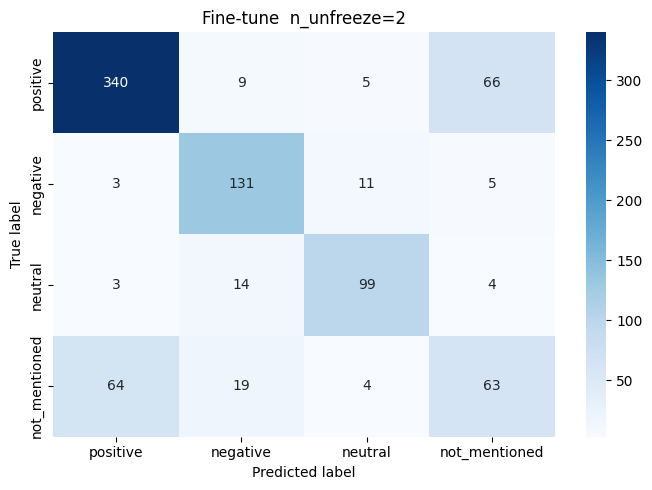

In [ ]:
### Fine-tune 3: classifier head with 2 unfreezing layers
from src.absa_model import run_finetune

model3_head, history3_head = run_finetune(train_df, val_df,
                                        output_dir   = "outputs",
                                        n_unfreeze   = 2,
                                        epochs       = 15,
                                        batch_size   = 16,
                                        lr           = 2e-5,
                                        head_lr_mult = 10.0,
                                        patience     = 5)


 FINE TUNING: n_unfreeze=3 | device=cuda


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5247.72it/s]


Trainable params: (11.9%)
Epoch 1/15  train_loss=1.0532  val_loss=0.7696  macro_F1=0.5716
  Saved best checkpoint to outputs/best_model_unfreeze3
Epoch 2/15  train_loss=0.7593  val_loss=0.6538  macro_F1=0.6205
  Saved best checkpoint to outputs/best_model_unfreeze3
Epoch 3/15  train_loss=0.6881  val_loss=0.6242  macro_F1=0.6383
  Saved best checkpoint to outputs/best_model_unfreeze3
Epoch 4/15  train_loss=0.6382  val_loss=0.6527  macro_F1=0.6414
  No improvement (1/5)
Epoch 5/15  train_loss=0.5812  val_loss=0.6111  macro_F1=0.7090
  Saved best checkpoint to outputs/best_model_unfreeze3
Epoch 6/15  train_loss=0.5239  val_loss=0.6128  macro_F1=0.6973
  No improvement (1/5)
Epoch 7/15  train_loss=0.4736  val_loss=0.5853  macro_F1=0.7429
  Saved best checkpoint to outputs/best_model_unfreeze3
Epoch 8/15  train_loss=0.4413  val_loss=0.5859  macro_F1=0.7464
  No improvement (1/5)
Epoch 9/15  train_loss=0.3930  val_loss=0.5891  macro_F1=0.7619
  No improvement (2/5)
Epoch 10/15  train_loss=0.

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 7271.03it/s]


  positive             Precision = 0.890  Recall = 0.714  F1 = 0.793  N = 420
  negative             Precision = 0.854  Recall = 0.780  F1 = 0.815  N = 150
  neutral              Precision = 0.775  Recall = 0.917  F1 = 0.840  N = 120
  not_mentioned        Precision = 0.438  Recall = 0.653  F1 = 0.524  N = 150

  Macro F1  : 0.7429
  Accuracy  : 0.7440


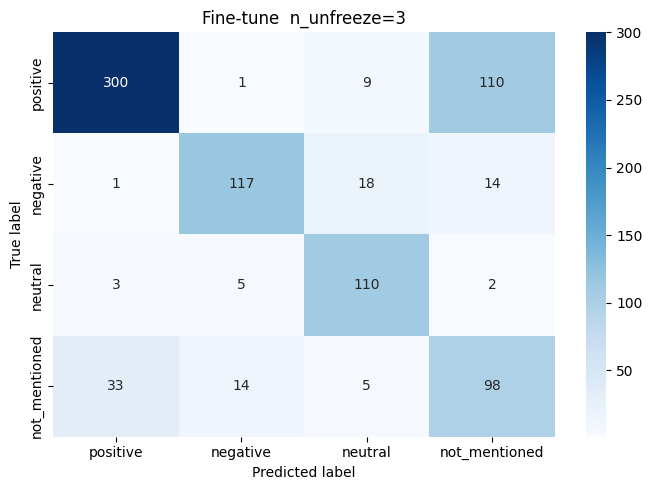

In [ ]:
### Fine-tune 4: classifier head with 3 unfreezing layers
from src.absa_model import run_finetune

model4_head, history4_head = run_finetune(train_df, val_df,
                                        output_dir   = "outputs",
                                        n_unfreeze   = 3,
                                        epochs       = 15,
                                        batch_size   = 16,
                                        lr           = 2e-5,
                                        head_lr_mult = 10.0,
                                        patience     = 5)


 FINE TUNING: n_unfreeze=4 | device=cuda


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 3174.10it/s]


Trainable params: (15.7%)
Epoch 1/10  train_loss=0.9715  val_loss=0.7203  macro_F1=0.5933
  Saved best checkpoint to outputs/best_model_unfreeze4
Epoch 2/10  train_loss=0.7255  val_loss=0.6278  macro_F1=0.6410
  Saved best checkpoint to outputs/best_model_unfreeze4
Epoch 3/10  train_loss=0.6407  val_loss=0.5880  macro_F1=0.7107
  Saved best checkpoint to outputs/best_model_unfreeze4
Epoch 4/10  train_loss=0.5465  val_loss=0.5751  macro_F1=0.7165
  Saved best checkpoint to outputs/best_model_unfreeze4
Epoch 5/10  train_loss=0.4992  val_loss=0.6125  macro_F1=0.7352
  No improvement (1/5)
Epoch 6/10  train_loss=0.4333  val_loss=0.5968  macro_F1=0.7485
  No improvement (2/5)
Epoch 7/10  train_loss=0.3901  val_loss=0.7011  macro_F1=0.7435
  No improvement (3/5)
Epoch 8/10  train_loss=0.3572  val_loss=0.6409  macro_F1=0.7612
  No improvement (4/5)
Epoch 9/10  train_loss=0.3098  val_loss=0.6626  macro_F1=0.7672
  No improvement (5/5)
  Early stopping.

Loading best checkpoint for final evalua

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4237.62it/s]


  positive             Precision = 0.824  Recall = 0.833  F1 = 0.828  N = 420
  negative             Precision = 0.781  Recall = 0.833  F1 = 0.806  N = 150
  neutral              Precision = 0.786  Recall = 0.917  F1 = 0.846  N = 120
  not_mentioned        Precision = 0.443  Recall = 0.340  F1 = 0.385  N = 150

  Macro F1  : 0.7165
  Accuracy  : 0.7571


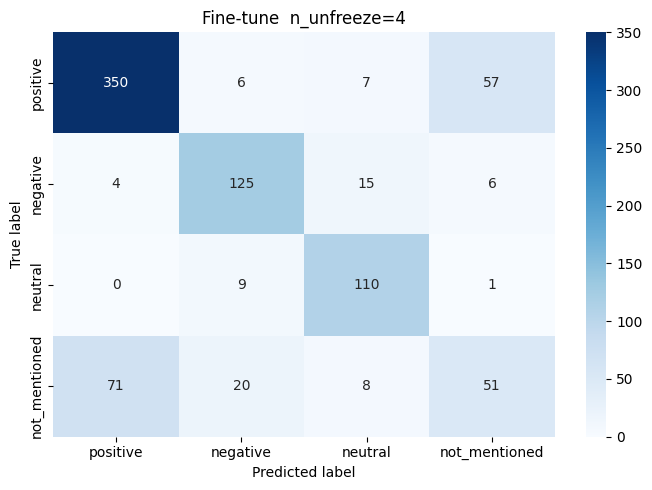

In [ ]:
### Fine-tune 5: classifier head with 4 unfreezing layers
from src.absa_model import run_finetune

model5_head, history5_head = run_finetune(train_df, val_df,
                                        output_dir   = "outputs",
                                        n_unfreeze   = 4,
                                        epochs       = 15,
                                        batch_size   = 16,
                                        lr           = 2e-5,
                                        head_lr_mult = 10.0,
                                        patience     = 5)

#### Figure for training and validation loss comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Compile the history data between each configurations

history_ft1 = {
    "config":    "FT-1 (0 layers)",
    "n_unfreeze": 0,
    "epoch":      list(range(1, 16)),
    "train_loss": [1.0657,0.8654,0.8337,0.8125,0.7871,0.7805,0.7738,0.7703,0.7560,0.7465,0.7503,0.7364,0.7365,0.7438,0.7354],
    "val_loss":   [0.8610,0.8126,0.8061,0.7607,0.7632,0.7222,0.7572,0.7012,0.7183,0.6845,0.7377,0.6879,0.6940,0.7103,0.6810],
    "macro_f1":   [0.5452,0.5652,0.5686,0.5813,0.5976,0.5984,0.6380,0.6028,0.5985,0.6080,0.6474,0.6208,0.6071,0.6101,0.6320],
    "best_epoch": 15,
    "stopped_at": 15,
}

history_ft2 = {
    "config":    "FT-2 (1 layer)",
    "n_unfreeze": 1,
    "epoch":      list(range(1, 16)),
    "train_loss": [1.0796,0.8347,0.7745,0.7410,0.7101,0.6990,0.6737,0.6555,0.6338,0.6165,0.6084,0.5890,0.5743,0.5562,0.5636],
    "val_loss":   [0.8449,0.7571,0.6998,0.6978,0.6868,0.6515,0.6262,0.6460,0.6284,0.6406,0.6427,0.6213,0.5839,0.6238,0.6149],
    "macro_f1":   [0.5508,0.6247,0.6443,0.6182,0.6321,0.6356,0.6785,0.6924,0.6654,0.6841,0.6920,0.6920,0.7213,0.6974,0.7058],
    "best_epoch": 13,
    "stopped_at": 15,
}

history_ft3 = {
    "config":    "FT-3 (2 layers)",
    "n_unfreeze": 2,
    "epoch":      list(range(1, 15)),   # early stop at epoch 14
    "train_loss": [1.0852,0.7839,0.7127,0.6672,0.6432,0.6065,0.5626,0.5262,0.5039,0.4871,0.4491,0.4227,0.4174,0.4015],
    "val_loss":   [0.8028,0.6920,0.6578,0.6346,0.6064,0.6329,0.5892,0.5678,0.5642,0.5848,0.5735,0.6523,0.6092,0.5909],
    "macro_f1":   [0.5800,0.6113,0.6207,0.7005,0.6958,0.6381,0.7051,0.7298,0.7241,0.7247,0.7498,0.7335,0.7295,0.7483],
    "best_epoch": 8,
    "stopped_at": 14,
}

history_ft4 = {
    "config":    "FT-4 (3 layers)",
    "n_unfreeze": 3,
    "epoch":      list(range(1, 13)),   # early stop at epoch 12
    "train_loss": [1.0532,0.7593,0.6881,0.6382,0.5812,0.5239,0.4736,0.4413,0.3930,0.3698,0.3429,0.3060],
    "val_loss":   [0.7696,0.6538,0.6242,0.6527,0.6111,0.6128,0.5853,0.5859,0.5891,0.6572,0.6731,0.7562],
    "macro_f1":   [0.5716,0.6205,0.6383,0.6414,0.7090,0.6973,0.7429,0.7464,0.7619,0.7511,0.7502,0.7416],
    "best_epoch": 7,
    "stopped_at": 12,
}

history_ft5 = {
    "config":    "FT-5 (4 layers)",
    "n_unfreeze": 4,
    "epoch":      list(range(1, 10)),   # early stop at epoch 9
    "train_loss": [0.9715,0.7255,0.6407,0.5465,0.4992,0.4333,0.3901,0.3572,0.3098],
    "val_loss":   [0.7203,0.6278,0.5880,0.5751,0.6125,0.5968,0.7011,0.6409,0.6626],
    "macro_f1":   [0.5933,0.6410,0.7107,0.7165,0.7352,0.7485,0.7435,0.7612,0.7672],
    "best_epoch": 4,
    "stopped_at": 9,
}

all_histories = [history_ft1, history_ft2, history_ft3, history_ft4, history_ft5]
rows = []
for h in all_histories:
    for i, ep in enumerate(h["epoch"]):
        rows.append({
            "config":     h["config"],
            "n_unfreeze": h["n_unfreeze"],
            "epoch":      ep,
            "train_loss": h["train_loss"][i],
            "val_loss":   h["val_loss"][i],
            "macro_f1":   h["macro_f1"][i],
            "best_epoch": h["best_epoch"],
            "stopped_at": h["stopped_at"],
            "early_stop": h["stopped_at"] < 15,
        })

history_df = pd.DataFrame(rows)
history_df.head(3)

,config,n_unfreeze,epoch,train_loss,val_loss,macro_f1,best_epoch,stopped_at,early_stop
0,FT-1 (0 layers),0,1,1.0657,0.8610,0.5452,15,15,False
1,FT-1 (0 layers),0,2,0.8654,0.8126,0.5652,15,15,False
2,FT-1 (0 layers),0,3,0.8337,0.8061,0.5686,15,15,False


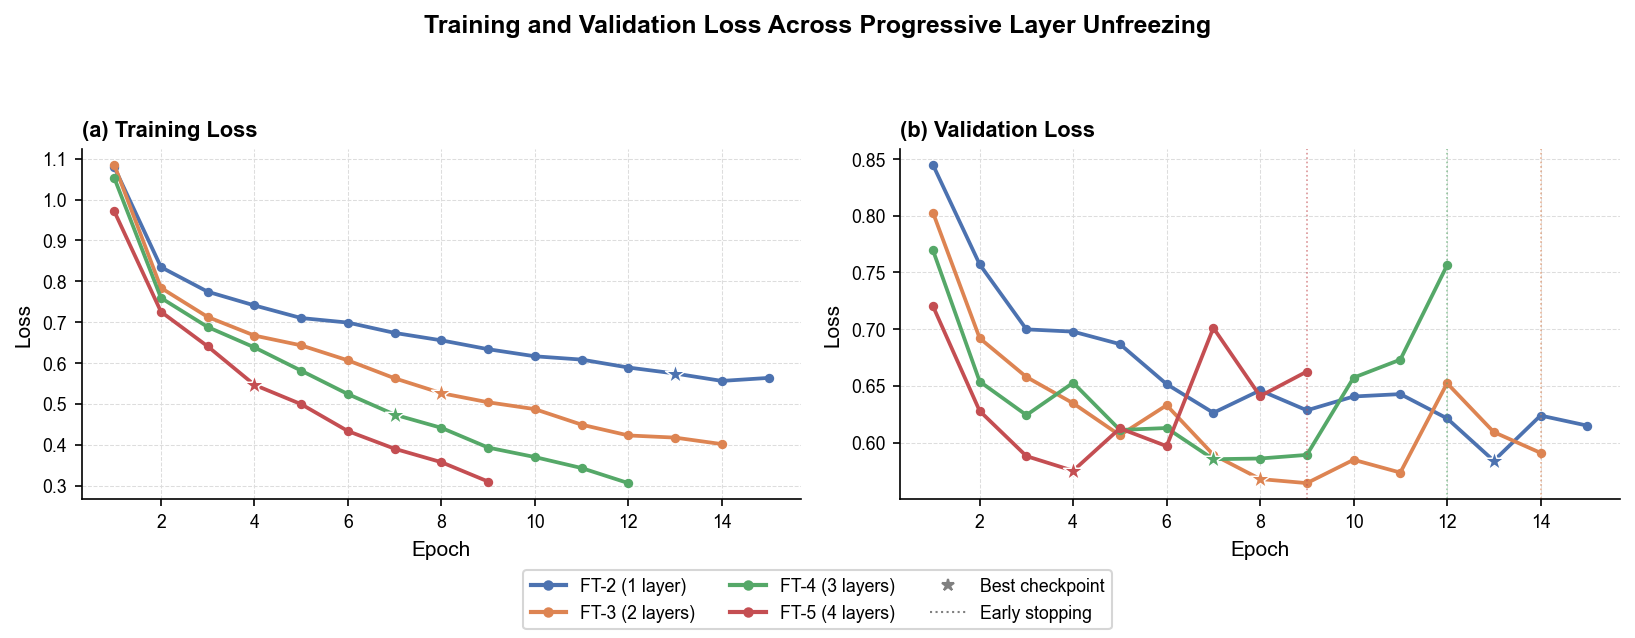

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D


### Plot to compare the training and validation loss across different fine-tuning configurations (with progressive layer unfreezing)

plot_df = history_df[history_df["n_unfreeze"] >= 1]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Arial", "DejaVu Serif"],
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#ddd",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "figure.dpi": 150,
})

PALETTE = {
    "FT-2 (1 layer)":  "#4C72B0",
    "FT-3 (2 layers)": "#DD8452",
    "FT-4 (3 layers)": "#55A868",
    "FT-5 (4 layers)": "#C44E52",
}

LW = 1.8
MS = 3.5

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, key, title in zip(
    axes,
    ["train_loss", "val_loss"],
    ["(a) Training Loss", "(b) Validation Loss"]
):

    for cfg, g in plot_df.groupby("config"):
        color = PALETTE[cfg]

        ax.plot(
            g["epoch"], g[key],
            color=color,
            linestyle="-",
            linewidth=LW,
            marker="o",
            markersize=MS,
            markerfacecolor=color,
            markeredgecolor=color,
            label=cfg
        )

        # Best checkpoint
        best = g[g["epoch"] == g["best_epoch"].iloc[0]]
        if not best.empty:
            ax.scatter(
                best["epoch"], best[key],
                marker="*",
                s=100,
                color=color,
                edgecolors="white",
                linewidths=0.7,
                zorder=5
            )

        # Early stopping
        if key == "val_loss" and g["early_stop"].iloc[0]:
            ax.axvline(
                g["stopped_at"].iloc[0],
                color=color,
                linestyle=":",
                linewidth=0.8,
                alpha=0.6
            )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

config_handles = [
    Line2D([0], [0], color=PALETTE[k], lw=2, marker="o",
           markersize=4, markerfacecolor=PALETTE[k], label=k)
    for k in PALETTE
]

extra_handles = [
    Line2D([0], [0], marker="*", color="gray", lw=0, label="Best checkpoint"),
    Line2D([0], [0], color="gray", ls=":", lw=1, label="Early stopping"),
]

fig.legend(
    handles=config_handles + extra_handles,
    loc="lower center",
    ncol=3,
    fontsize=8.5
)

fig.suptitle("Training and Validation Loss Across Progressive Layer Unfreezing", fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.savefig("loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()